In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
dirname = '/kaggle/input/titanic/'
train = pd.read_csv(dirname+'train.csv')
test = pd.read_csv(dirname+'test.csv')

train_x = train.drop(['Survived'], axis=1)
train_y = train['Survived']

test_x = test.copy()

# violin plot

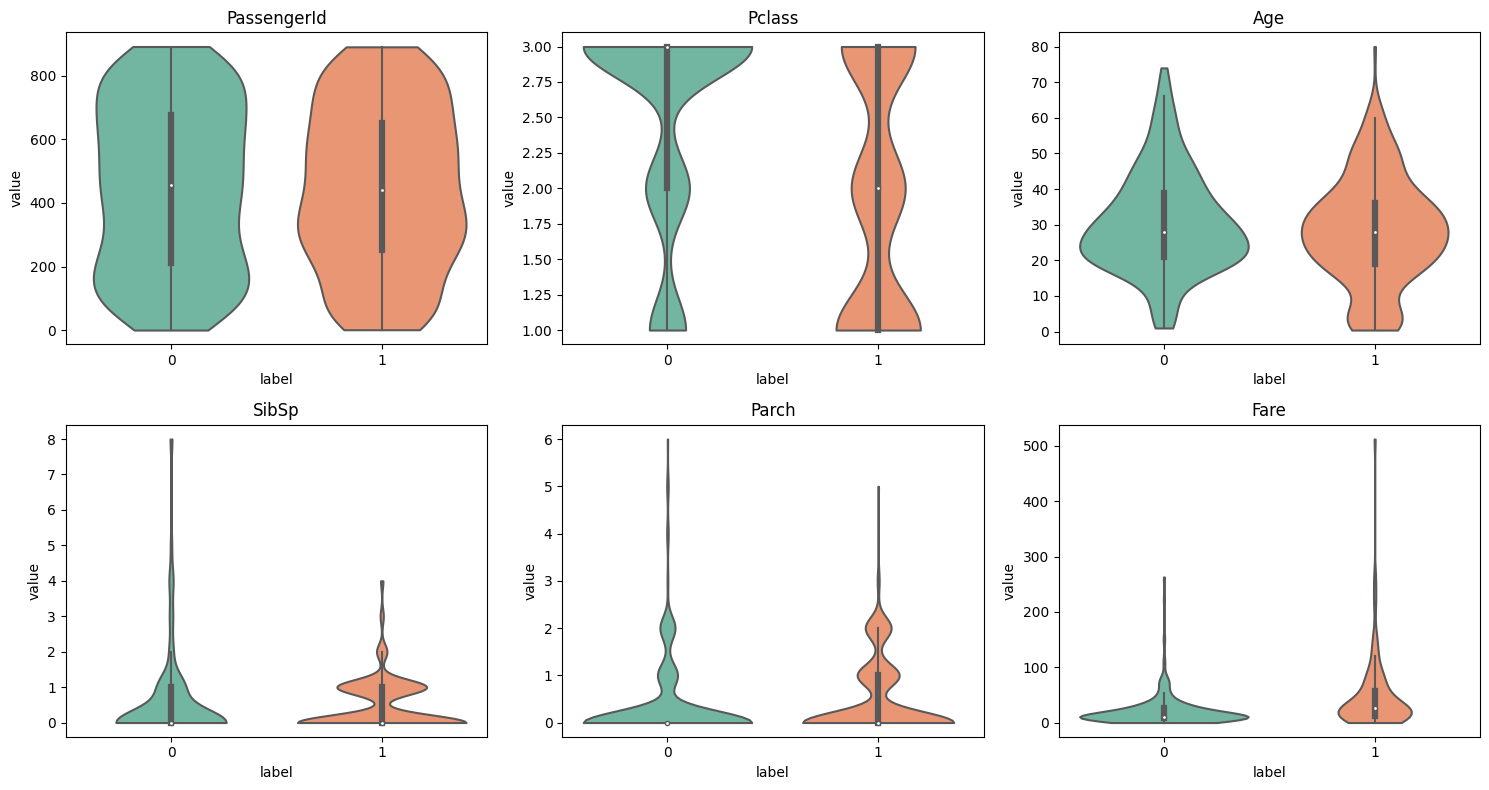

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

# 数値列のみを選択
num_cols = train_x.select_dtypes(include='number').columns
n_cols = len(num_cols)

# レイアウト設定
n_per_row = 3
n_rows = math.ceil(n_cols / n_per_row)

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# 各列ごとに描画
for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.violinplot(
        x=train_y, y=train_x[col],
        ax=ax,
        inner='box',        # 中央値と四分位範囲を表示
        cut=0,              # 外れ値部分を伸ばさない
        palette='Set2',     # カラーテーマ
        bw=0.3              # 平滑化の強さ（値が小さいほど細かい形になる）
    )
    ax.set_title(col)
    ax.set_xlabel("label")
    ax.set_ylabel("value")

# 余分な空白プロットを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# line chart

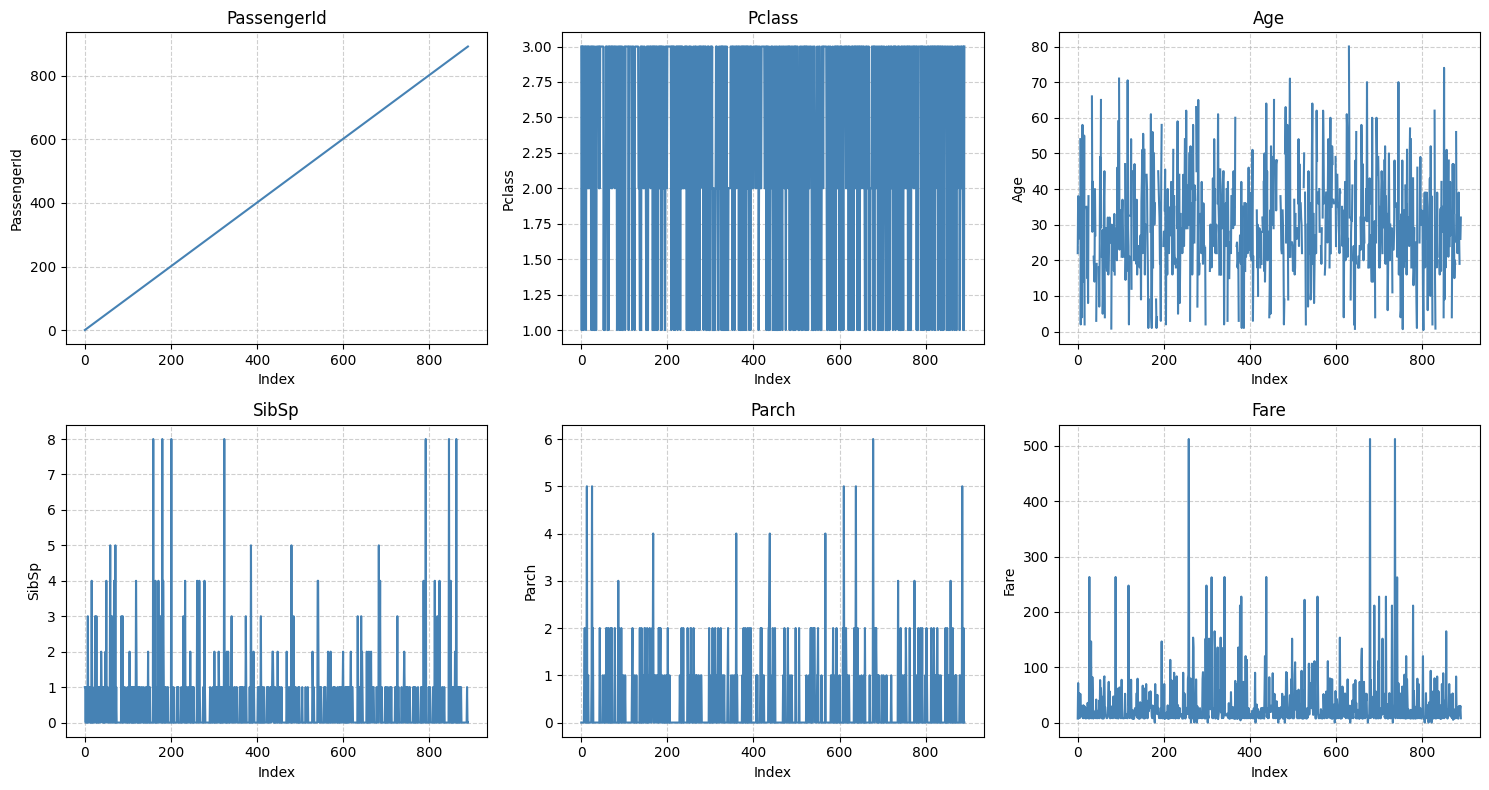

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import math

num_cols = train_x.select_dtypes(include='number').columns
n_cols = len(num_cols)

n_per_row = 3
n_rows = math.ceil(n_cols / n_per_row)

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.plot(train_x.index, train_x[col], color='steelblue')
    ax.set_title(col)
    ax.set_xlabel("Index")
    ax.set_ylabel(col)
    ax.grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# heat map

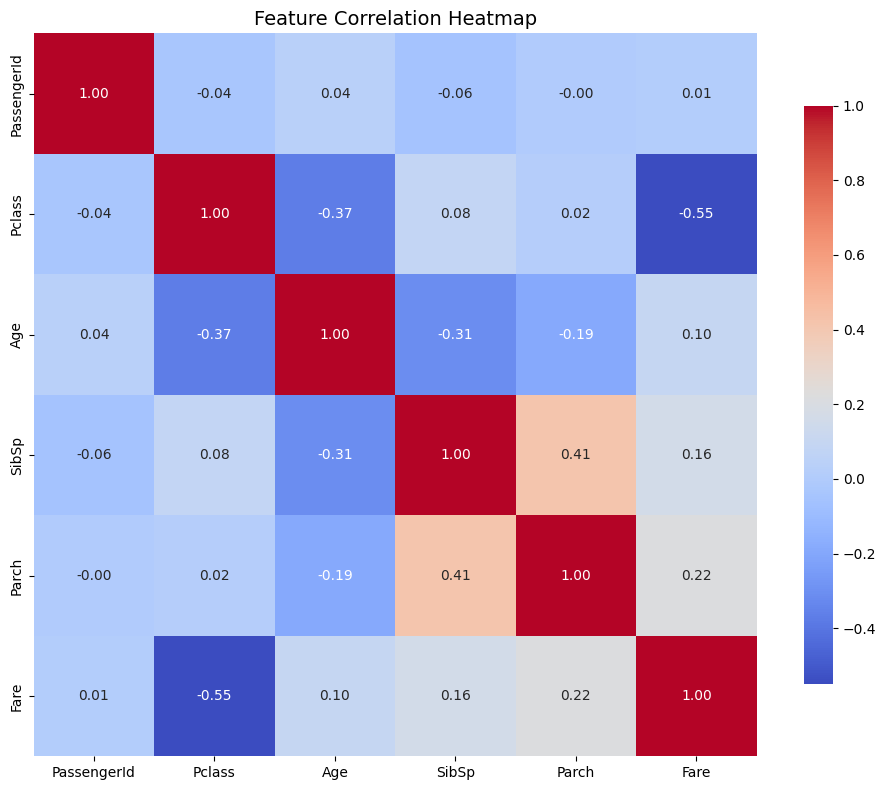

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 数値列のみ
num_cols = train_x.select_dtypes(include='number')

# 相関行列
corr = num_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',      # 色のスキーム
    annot=True,           # 相関係数をセル内に表示
    fmt=".2f",            # 小数2桁
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()



# Q-Q plot

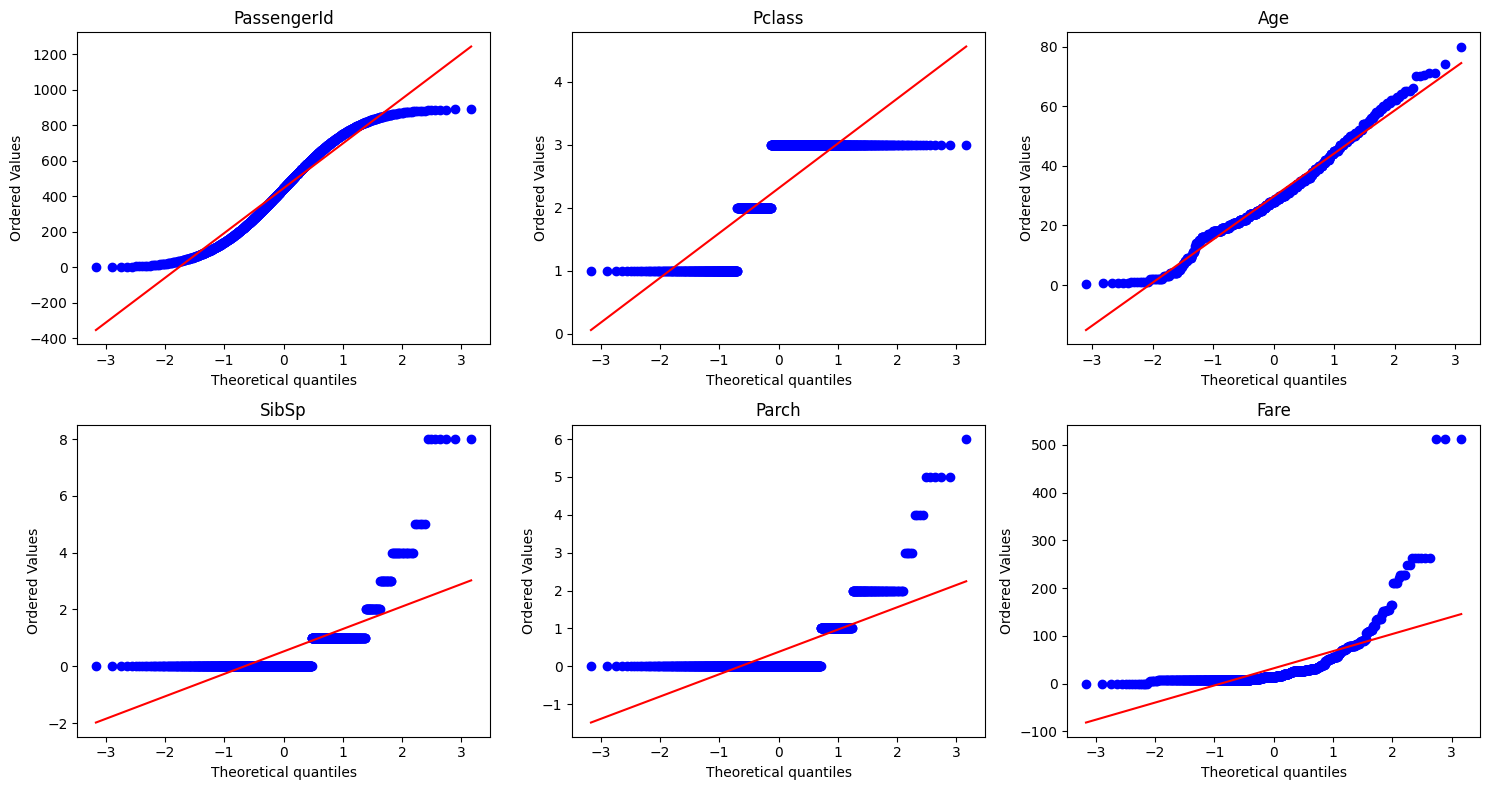

In [6]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import math

num_cols = train_x.select_dtypes(include='number').columns
n_per_row = 3
n_rows = math.ceil(len(num_cols) / n_per_row)

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = train_x[col].dropna()
    if len(data) == 0:
        ax.set_visible(False)
        continue
    stats.probplot(data, dist="norm", plot=ax)   # Q-Q plot
    ax.set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# t-SNE

次元削除で可視化

In [9]:
train_x.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

# --- select numeric features only ---
X = train_x.select_dtypes(include='number').dropna(axis=1)
y = train_y


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 891 samples in 0.001s...
[t-SNE] Computed neighbors for 891 samples in 0.019s...
[t-SNE] Computed conditional probabilities for sample 891 / 891
[t-SNE] Mean sigma: 16.404286
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.036194
[t-SNE] KL divergence after 1000 iterations: 0.303549


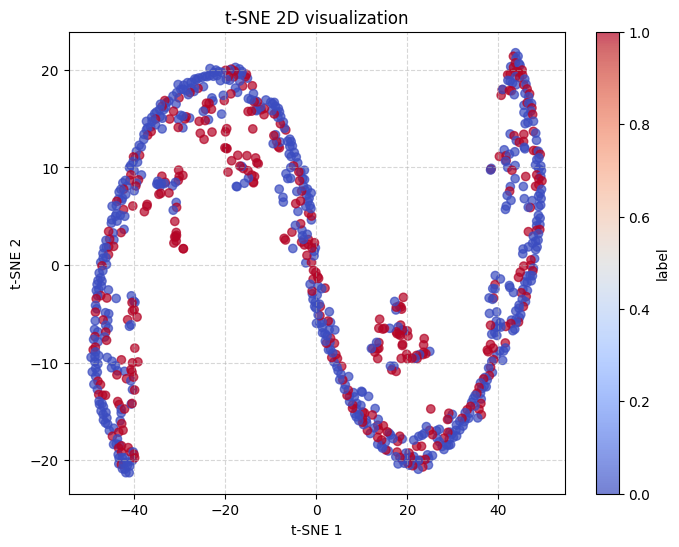

In [17]:

# --- run t-SNE ---
tsne = TSNE(
    n_components=2,   # 2D embedding
    perplexity=30,    # neighborhood size (try 5–50)
    learning_rate=200,
    random_state=42,
    n_iter=1000,
    verbose=1
)
X_embedded = tsne.fit_transform(X)

# --- plot ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_embedded[:,0], X_embedded[:,1],
                      c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='label')
plt.title("t-SNE 2D visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [18]:
X_embedded

array([[ 43.75958 ,  21.767616],
       [ 40.605804,  17.400433],
       [ 43.294113,  21.402771],
       ...,
       [-40.31469 , -20.055666],
       [-39.814606, -19.762365],
       [-41.009666, -21.294327]], dtype=float32)

# UMAP

In [20]:
import umap

In [21]:
# --- run UMAP ---
reducer = umap.UMAP(
    n_components=2,      # output dimension (2D)
    n_neighbors=15,      # size of local neighborhood
    min_dist=0.1,        # how tightly points are packed
    metric='euclidean',  # distance metric
    random_state=42
)
X_embedded = reducer.fit_transform(X)

# --- plot ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_embedded[:,0], X_embedded[:,1],
                      c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='label')
plt.title("UMAP 2D Visualization")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

TypeError: check_array() got an unexpected keyword argument 'ensure_all_finite'

In [7]:
#可視化手法
# 1. bar chart
# 2. box plot, violin plot
# 3. scatter plot
# 4. line chart
# 5. heat map
# 6. histogram
# 7. Q-Q plot
# 8. t-SNE, UMAP